In [5]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=(5-1)//2), 
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16*5*5, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),  
    nn.Linear(84, 10)
    )

X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:   
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)      


Conv2d output shape:	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size)
test_dataloader = DataLoader(test_data, batch_size)



实战

Using device: cuda
epoch  1 | train_loss 0.685 | train_acc 0.745 | test_acc 0.805
epoch  2 | train_loss 0.436 | train_acc 0.839 | test_acc 0.835
epoch  3 | train_loss 0.375 | train_acc 0.860 | test_acc 0.853
epoch  4 | train_loss 0.343 | train_acc 0.874 | test_acc 0.863
epoch  5 | train_loss 0.319 | train_acc 0.882 | test_acc 0.871
epoch  6 | train_loss 0.300 | train_acc 0.888 | test_acc 0.879
epoch  7 | train_loss 0.286 | train_acc 0.893 | test_acc 0.882
epoch  8 | train_loss 0.273 | train_acc 0.898 | test_acc 0.886
epoch  9 | train_loss 0.261 | train_acc 0.902 | test_acc 0.887
epoch 10 | train_loss 0.252 | train_acc 0.906 | test_acc 0.872
epoch 11 | train_loss 0.242 | train_acc 0.909 | test_acc 0.889
epoch 12 | train_loss 0.234 | train_acc 0.913 | test_acc 0.888
epoch 13 | train_loss 0.225 | train_acc 0.916 | test_acc 0.895
epoch 14 | train_loss 0.218 | train_acc 0.918 | test_acc 0.895
epoch 15 | train_loss 0.212 | train_acc 0.921 | test_acc 0.890
epoch 16 | train_loss 0.205 | train_

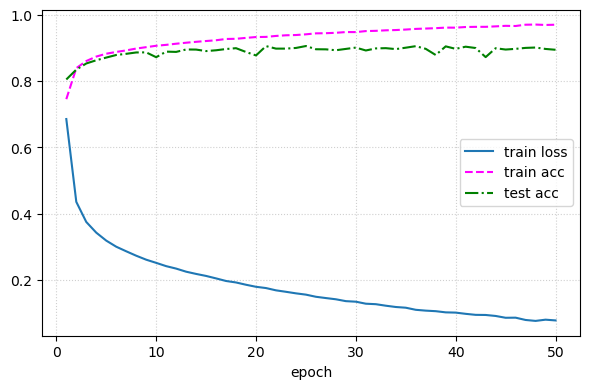

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets 
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

# ---------- data ----------
batch_size = 64
training_data = datasets.FashionMNIST(root="data", train=True,  download=True, transform=ToTensor())
test_data     = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())
train_dataloader = DataLoader(training_data, batch_size, shuffle=True)
test_dataloader  = DataLoader(test_data,     batch_size, shuffle=False)

# ---------- device ----------
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ---------- network ----------
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=(5-1)//2), 
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16*5*5, 120),
    nn.ReLU(),
    nn.Linear(120, 84),
    nn.ReLU(),  
    nn.Linear(84, 10)
    )

def init_cnn(m): # 定义一个函数,参数 m 是网络里的某一个「层」(module)
    if type(m) in (nn.Linear, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)  # 对该层的权重 m.weight 做 Xavier 均匀初始化(也叫 Glorot 初始化)。
net.apply(init_cnn) # apply 会递归遍历 net 里的每一个子模块,对每个都调用一次 init_cnn。也就是把上面的初始化规则应用到整个网络的所有层。
net.to(device) # 把整个网络的参数和缓冲区移动到 device(就是上一段选的 cuda / mps / cpu)。这样网络才能和同样在该设备上的数据一起做运算。

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

# ---------- 评估函数:返回 (loss, acc) ----------
def evaluate(dataloader):
    net.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = net(X)
            total_loss += loss_fn(logits, y).item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n

# ---------- 训练循环:每个 epoch 记录三条曲线 ----------
num_epochs = 50
history = {"train_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(num_epochs):
    net.train()
    running_loss, correct, n = 0.0, 0, 0
    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad() # clear gradient
        logits = net(X) # forward propagation
        loss = loss_fn(logits, y) # calculate loss
        loss.backward() # backward propagation
        optimizer.step() #  renew the gradient

        running_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()   # 顺手统计训练准确率
        n += y.size(0)

    train_loss = running_loss / n
    train_acc  = correct / n
    _, test_acc = evaluate(test_dataloader)               # 测试集只取准确率

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    print(f"epoch {epoch+1:2d} | train_loss {train_loss:.3f} "
          f"| train_acc {train_acc:.3f} | test_acc {test_acc:.3f}")

# ---------- 画图 ----------
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], '-',  color='tab:blue',  label='train loss')
plt.plot(epochs, history["train_acc"],  '--', color='magenta',   label='train acc')
plt.plot(epochs, history["test_acc"],   '-.', color='green',     label='test acc')
plt.xlabel('epoch')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('lenet_training.png', dpi=150)   # 存成文件,方便你放进笔记
plt.show()